# Demand Forecasting

This notebook focuses on developing machine learning models for forecasting electricity demand in Germany. The engineered dataset created in the previous notebook serves as the foundation for model training, evaluation, and comparison.

## Loading the Engineered Dataset

The engineered dataset containing demand, weather, renewable energy, temporal, and lag-based features was loaded for forecasting analysis.

In [31]:
import pandas as pd

model_df = pd.read_csv(
    "../data/processed/master_features.csv"
)

print(model_df.shape)

model_df.head()

(50232, 29)


,utc_timestamp,DE_load_actual_entsoe_transparency,DE_solar_generation_actual,DE_wind_generation_actual,DE_solar_capacity,DE_wind_capacity,DE_LU_price_day_ahead,time,temperature_C,humidity_pct,...,week_of_year,season,renewable_generation,renewable_share_pct,load_lag_1,load_lag_24,load_lag_168,rolling_mean_24,hour_sin,hour_cos
0,2015-01-08 00:00:00+00:00,48041.0,0.0,15807.0,37258.0,27966.0,NaN,2015-01-08 00:00:00+00:00,1.56,86.8,...,2,Winter,15807.0,32.903145,50460.0,45125.0,41151.0,60234.500000,0.000000,1.000000
1,2015-01-08 01:00:00+00:00,47074.0,0.0,16449.0,37258.0,27966.0,NaN,2015-01-08 01:00:00+00:00,1.70,86.0,...,2,Winter,16449.0,34.942856,48041.0,44217.0,40135.0,60353.541667,0.258819,0.965926
2,2015-01-08 02:00:00+00:00,47228.0,0.0,16695.0,37258.0,27966.0,NaN,2015-01-08 02:00:00+00:00,1.90,84.0,...,2,Winter,16695.0,35.349792,47074.0,44368.0,39106.0,60472.708333,0.500000,0.866025
3,2015-01-08 03:00:00+00:00,48253.0,0.0,16787.0,37258.0,27966.0,NaN,2015-01-08 03:00:00+00:00,2.20,83.6,...,2,Winter,16787.0,34.789547,47228.0,45298.0,38765.0,60595.833333,0.707107,0.707107
4,2015-01-08 04:00:00+00:00,51155.0,0.0,16751.0,37258.0,27966.0,NaN,2015-01-08 04:00:00+00:00,2.42,84.2,...,2,Winter,16751.0,32.745577,48253.0,48598.0,38941.0,60702.375000,0.866025,0.500000


### Dataset Overview

The engineered forecasting dataset was successfully loaded for model development. The dataset contains 50,232 observations and 29 variables, including electricity demand, weather conditions, renewable energy metrics, temporal indicators, lagged demand features, rolling statistics, and cyclical time representations.

The dataset represents the final output of the feature engineering workflow and serves as the foundation for training and evaluating electricity demand forecasting models.

## Data Quality Verification

Before model development, the dataset was inspected to verify data types and identify any remaining missing values that could affect model training and evaluation.

In [32]:
model_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50232 entries, 0 to 50231
Data columns (total 29 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   utc_timestamp                       50232 non-null  str    
 1   DE_load_actual_entsoe_transparency  50232 non-null  float64
 2   DE_solar_generation_actual          50232 non-null  float64
 3   DE_wind_generation_actual           50232 non-null  float64
 4   DE_solar_capacity                   50232 non-null  float64
 5   DE_wind_capacity                    50232 non-null  float64
 6   DE_LU_price_day_ahead               17540 non-null  float64
 7   time                                50232 non-null  str    
 8   temperature_C                       50232 non-null  float64
 9   humidity_pct                        50232 non-null  float64
 10  cloud_cover_pct                     50232 non-null  float64
 11  wind_speed_ms                       50232 non-null  

### Data Quality Verification

The forecasting dataset was inspected to verify data completeness and variable types. All demand, weather, renewable energy, temporal, lagged, rolling, and cyclical features contained complete observations suitable for machine learning.

The electricity price variable contained substantial missing data, consistent with findings from the feature engineering stage. Consequently, this feature will be excluded from the initial forecasting models to preserve the full sample size. Timestamp variables were stored as strings following dataset export; however, their temporal information has already been captured through engineered calendar and cyclical features.

## Defining Target and Predictor Variables

The target variable was defined as electricity demand, while predictor variables consisted of weather, renewable energy, temporal, lagged, rolling, and cyclical features. Timestamp fields and electricity price data were excluded from the initial forecasting models.

In [33]:
target = 'DE_load_actual_entsoe_transparency'

features = [
    col for col in model_df.columns
    if col not in [
        'DE_load_actual_entsoe_transparency',
        'utc_timestamp',
        'time',
        'DE_LU_price_day_ahead'
    ]
]

X = model_df[features]
y = model_df[target]

print("Number of features:", len(features))
print("X shape:", X.shape)
print("y shape:", y.shape)

Number of features: 25
X shape: (50232, 25)
y shape: (50232,)


## Train-Test Split

Electricity demand forecasting is a time-series problem; therefore, the dataset was split chronologically rather than randomly. Earlier observations were used for training, while more recent observations were reserved for testing to simulate real-world forecasting conditions.

In [34]:
split_idx = int(len(model_df) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 40185
Testing samples: 10047


### Time-Series Data Partitioning

The dataset was divided into training and testing subsets using an 80:20 chronological split. A total of 40,185 observations were used for model training, while 10,047 observations were reserved for out-of-sample evaluation.

By preserving temporal order, the split mimics real-world forecasting scenarios in which future electricity demand is predicted using only historical information.

## Baseline Forecast Model

A persistence forecasting approach was used as the baseline model. This method assumes that electricity demand at the current time step is equal to demand during the previous hour. Baseline performance provides a benchmark against which machine learning models can be evaluated.

In [35]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

baseline_pred = X_test['load_lag_1']

baseline_mae = mean_absolute_error(
    y_test,
    baseline_pred
)

baseline_rmse = root_mean_squared_error(
    y_test,
    baseline_pred
)

baseline_r2 = r2_score(
    y_test,
    baseline_pred
)

print("Baseline MAE :", round(baseline_mae, 2))
print("Baseline RMSE:", round(baseline_rmse, 2))
print("Baseline R²  :", round(baseline_r2, 4))

Baseline MAE : 1877.82
Baseline RMSE: 2461.99
Baseline R²  : 0.9374


### Baseline Forecast Performance

A persistence forecasting model was used as the baseline benchmark, where electricity demand at the current hour was assumed to be equal to demand during the previous hour.

The baseline model achieved an MAE of 1,877.82 MW, an RMSE of 2,461.99 MW, and an R² score of 0.9374. These results indicate strong temporal persistence in electricity demand, with more than 93% of demand variability explained by the previous hour's demand alone.

All subsequent machine learning models must outperform this baseline to demonstrate added predictive value.

## Identifying Non-Numeric Features

Machine learning algorithms such as linear regression require numerical input variables. The feature set was inspected to identify categorical variables that require encoding before model training.

In [36]:
X.dtypes[X.dtypes == 'object']

Series([], dtype: object)

### Feature Type Verification

Prior to model training, predictor variables were inspected to ensure compatibility with machine learning algorithms. Numerical models such as linear regression require all input features to be represented numerically. Therefore, any remaining non-numeric variables must be identified and appropriately encoded or removed before training.

In [37]:
X.select_dtypes(exclude=['number']).columns.tolist()

['season']

## Encoding Seasonal Information

The season variable is categorical and therefore cannot be directly processed by linear regression. One-hot encoding was applied to transform seasonal categories into numerical indicator variables while preserving seasonal information.

In [38]:
X = pd.get_dummies(
    X,
    columns=['season'],
    drop_first=True
)

print(X.shape)

(50232, 27)


### Seasonal Feature Encoding

The categorical season variable was transformed into numerical indicator variables using one-hot encoding. This process replaced a single non-numeric feature with multiple binary seasonal indicators, increasing the predictor set from 25 to 27 features.

The transformation preserves seasonal information while ensuring compatibility with machine learning algorithms such as linear regression. Because the predictor matrix changed after encoding, the train-test split was recreated to ensure that the updated feature set was consistently represented in both training and testing datasets.

## Updating the Modeling Dataset

Following seasonal feature encoding, the predictor matrix was updated and the chronological train-test split was recreated to ensure consistency during model training and evaluation.

In [39]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]

y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

print(X_train.shape)
print(X_test.shape)

(40185, 27)
(10047, 27)


### Updated Modeling Dataset

Following one-hot encoding of the seasonal feature, the predictor matrix increased from 25 to 27 variables. The train-test partition was subsequently recreated to ensure that the updated feature set was consistently represented in both training and testing subsets.

This step maintains the integrity of the forecasting workflow and ensures that all engineered features are available during model development and evaluation.

## Linear Regression Model

A multiple linear regression model was developed using the engineered feature set. The model serves as a simple yet interpretable machine learning baseline for evaluating the predictive value of the engineered features.

In [40]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(X_test)

print("Linear Regression trained successfully.")

Linear Regression trained successfully.


## Evaluating Linear Regression Performance

The trained Linear Regression model was evaluated on the test dataset using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). These metrics were compared directly against the persistence baseline to assess whether the engineered features provide additional predictive value.

In [41]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

lr_mae = mean_absolute_error(
    y_test,
    lr_pred
)

lr_rmse = root_mean_squared_error(
    y_test,
    lr_pred
)

lr_r2 = r2_score(
    y_test,
    lr_pred
)

print("Linear Regression MAE :", round(lr_mae, 2))
print("Linear Regression RMSE:", round(lr_rmse, 2))
print("Linear Regression R²  :", round(lr_r2, 4))

Linear Regression MAE : 1168.2
Linear Regression RMSE: 1490.44
Linear Regression R²  : 0.9771


### Linear Regression Performance

The Linear Regression model substantially outperformed the persistence baseline across all evaluation metrics. The model achieved an MAE of 1,168.20 MW, an RMSE of 1,490.44 MW, and an R² score of 0.9771.

Compared with the persistence forecast, the Linear Regression model reduced forecasting errors by approximately 38–40% while increasing explained variance from 93.74% to 97.71%. These results demonstrate that the engineered weather, renewable energy, temporal, lagged, rolling, and seasonal features provide substantial predictive value beyond simple demand persistence.

The strong performance also confirms the effectiveness of the feature engineering strategy developed in the previous notebook.

## Linear Regression Coefficient Analysis

Model coefficients were examined to identify the variables with the strongest positive and negative influence on electricity demand forecasts.

In [42]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr_model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()

coef_df = coef_df.sort_values(
    'Abs_Coefficient',
    ascending=False
)

coef_df.head(15)

,Feature,Coefficient,Abs_Coefficient
22,hour_sin,1989.292717,1989.292717
23,hour_cos,-963.879840,963.879840
12,year,506.281383,506.281383
13,is_weekend,-274.447940,274.447940
26,season_Winter,-237.538493,237.538493
24,season_Spring,-171.509180,171.509180
17,renewable_share_pct,-143.079319,143.079319
10,day_of_week,-142.291776,142.291776
14,quarter,111.133881,111.133881
9,hour,-62.044195,62.044195


### Interpretation of Linear Regression Coefficients

The largest regression coefficients were associated with cyclical time variables, seasonal indicators, weekend effects, and renewable energy share. These results suggest that daily demand cycles and calendar-related patterns play an important role in explaining electricity demand variability.

However, coefficient magnitudes should be interpreted cautiously because predictor variables are measured on different scales. Variables such as lagged demand and renewable generation have much larger numerical ranges than cyclical features, making direct coefficient comparisons potentially misleading. A standardized coefficient analysis would provide a more reliable assessment of relative feature importance.

## Standardized Feature Importance

To enable meaningful comparison of feature effects, predictor variables were standardized prior to model fitting. Standardized coefficients were then examined to identify the variables with the strongest relative influence on electricity demand forecasts.

In [43]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr_scaled = LinearRegression()

lr_scaled.fit(
    X_train_scaled,
    y_train
)

coef_scaled = pd.DataFrame({
    'Feature': X_train.columns,
    'Standardized_Coefficient': lr_scaled.coef_
})

coef_scaled['Abs_Coefficient'] = (
    coef_scaled['Standardized_Coefficient']
    .abs()
)

coef_scaled.sort_values(
    'Abs_Coefficient',
    ascending=False
).head(15)

,Feature,Standardized_Coefficient,Abs_Coefficient
18,load_lag_1,7833.460336,7833.460336
17,renewable_share_pct,-2432.850781,2432.850781
22,hour_sin,1406.666245,1406.666245
1,DE_wind_generation_actual,1380.012524,1380.012524
20,load_lag_168,1221.141651,1221.141651
16,renewable_generation,959.328000,959.328000
19,load_lag_24,882.846845,882.846845
23,hour_cos,-681.554381,681.554381
12,year,677.560693,677.560693
21,rolling_mean_24,-605.155745,605.155745


### Standardized Feature Importance

Standardized coefficients revealed that lagged demand variables are the most influential predictors of electricity demand. The previous hour's demand (**load_lag_1**) exhibited the strongest effect, confirming the high temporal persistence observed during exploratory analysis.

Other important predictors included renewable energy share, wind generation, weekly demand patterns (**load_lag_168**), and cyclical hourly features. The prominence of these variables indicates that electricity demand is driven by a combination of historical consumption patterns, renewable generation dynamics, and recurring temporal cycles.

The results validate the feature engineering strategy and confirm that the strongest forecasting signals originate from both demand history and renewable energy system behavior.

## Random Forest Regression Model

A Random Forest Regressor was developed to capture nonlinear relationships between electricity demand and the engineered predictor variables. Unlike linear regression, Random Forest can model complex interactions among weather, renewable energy, temporal, and lag-based features without requiring feature scaling.

In [44]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained successfully.")

Random Forest trained successfully.


### Random Forest Model Development

A Random Forest Regressor was trained using the engineered feature set. Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve predictive accuracy and robustness. Unlike linear regression, it can capture nonlinear relationships and interactions among predictor variables without requiring feature standardization.

## Evaluating Random Forest Performance

The Random Forest model was evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). The results were compared against both the persistence baseline and the Linear Regression model to determine whether nonlinear modeling improves forecasting performance.

In [45]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = root_mean_squared_error(
    y_test,
    rf_pred
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest MAE :", round(rf_mae, 2))
print("Random Forest RMSE:", round(rf_rmse, 2))
print("Random Forest R²  :", round(rf_r2, 4))

Random Forest MAE : 536.23
Random Forest RMSE: 734.49
Random Forest R²  : 0.9944


### Random Forest Performance

The Random Forest model substantially outperformed both the persistence baseline and the Linear Regression model. The model achieved an MAE of 536.23 MW, an RMSE of 734.49 MW, and an R² score of 0.9944.

Compared with Linear Regression, forecasting errors were reduced by more than 50%, while explained variance increased from 97.71% to 99.44%. These results indicate that electricity demand exhibits nonlinear relationships and feature interactions that are effectively captured by the Random Forest algorithm.

The strong performance demonstrates the value of the engineered lag, renewable energy, weather, and temporal features, and establishes Random Forest as the best-performing forecasting model evaluated so far.

## Model Performance Comparison

The forecasting performance of all evaluated models was compared using MAE, RMSE, and R² metrics. This comparison highlights the incremental value of machine learning and nonlinear modeling approaches relative to the persistence baseline.

In [46]:
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest'
    ],
    'MAE': [
        baseline_mae,
        lr_mae,
        rf_mae
    ],
    'RMSE': [
        baseline_rmse,
        lr_rmse,
        rf_rmse
    ],
    'R2': [
        baseline_r2,
        lr_r2,
        rf_r2
    ]
})

comparison_df

,Model,MAE,RMSE,R2
0,Baseline,1877.816064,2461.993466,0.937431
1,Linear Regression,1168.197378,1490.436887,0.977070
2,Random Forest,536.228592,734.493811,0.994431


### Comparative Model Performance

A comparison of forecasting models revealed consistent improvements in predictive accuracy as model complexity increased. The persistence baseline achieved an R² score of 0.9374, demonstrating strong temporal dependence in electricity demand.

Linear Regression significantly improved forecasting performance, increasing explained variance to 97.71% while reducing forecasting errors by approximately 40%. The Random Forest model delivered the best overall performance, achieving an R² score of 0.9944 and reducing forecasting errors by more than 70% relative to the persistence baseline.

These results indicate that electricity demand is influenced by complex nonlinear interactions among historical demand, renewable generation, weather conditions, and temporal factors, which are effectively captured by ensemble learning methods.

## Random Forest Feature Importance

Feature importance scores were extracted from the Random Forest model to identify the variables that contribute most strongly to electricity demand forecasting.

In [47]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    'Importance',
    ascending=False
)

importance_df.head(15)

,Feature,Importance
18,load_lag_1,0.915915
20,load_lag_168,0.034885
22,hour_sin,0.018844
9,hour,0.013349
19,load_lag_24,0.005039
23,hour_cos,0.003292
21,rolling_mean_24,0.002877
0,DE_solar_generation_actual,0.002026
4,temperature_C,0.000598
10,day_of_week,0.000484


### Random Forest Feature Importance

Feature importance analysis revealed that the previous hour's electricity demand (**load_lag_1**) is by far the most influential predictor, accounting for more than 91% of the model's predictive importance. This finding highlights the strong temporal persistence present in electricity demand patterns.

Additional important predictors included weekly demand history (**load_lag_168**), cyclical hourly features (**hour_sin**, **hour**, and **hour_cos**), and daily demand history (**load_lag_24**). Weather-related variables exhibited comparatively low importance, suggesting that much of their predictive information is already embedded within historical demand observations.

These results indicate that short-term electricity demand forecasting is primarily driven by autoregressive demand behavior, with weather and renewable generation providing supplementary predictive information.

## Sensitivity Analysis: Removing the Previous-Hour Demand Feature

To evaluate the dependence of the forecasting model on immediate demand persistence, the most influential predictor (`load_lag_1`) was removed and the Random Forest model was retrained. This experiment helps identify alternative drivers of electricity demand when previous-hour demand information is unavailable.

In [48]:
# Remove load_lag_1

X_no_lag1 = X.drop(columns=['load_lag_1'])

# Chronological split

split_idx = int(len(X_no_lag1) * 0.8)

X_train_nl1 = X_no_lag1.iloc[:split_idx]
X_test_nl1 = X_no_lag1.iloc[split_idx:]

# Train Random Forest

rf_no_lag1 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_no_lag1.fit(
    X_train_nl1,
    y_train
)

rf_no_lag1_pred = rf_no_lag1.predict(
    X_test_nl1
)

print("Random Forest without load_lag_1 trained successfully.")

Random Forest without load_lag_1 trained successfully.


## Performance Impact of Removing Immediate Demand Persistence

The Random Forest model trained without **load_lag_1** was evaluated using the same performance metrics as previous models. The resulting performance was compared against the original Random Forest model to quantify the contribution of immediate demand persistence to forecasting accuracy.

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

rf_no_lag1_mae = mean_absolute_error(
    y_test,
    rf_no_lag1_pred
)

rf_no_lag1_rmse = root_mean_squared_error(
    y_test,
    rf_no_lag1_pred
)

rf_no_lag1_r2 = r2_score(
    y_test,
    rf_no_lag1_pred
)

print("RF without load_lag_1 MAE :", round(rf_no_lag1_mae, 2))
print("RF without load_lag_1 RMSE:", round(rf_no_lag1_rmse, 2))
print("RF without load_lag_1 R²  :", round(rf_no_lag1_r2, 4))

RF without load_lag_1 MAE : 1443.29
RF without load_lag_1 RMSE: 2182.36
RF without load_lag_1 R²  : 0.9508


### Impact of Removing the Previous-Hour Demand Feature

The removal of *load_lag_1* resulted in a substantial decline in forecasting performance. The Random Forest model's R² score decreased from 0.9944 to 0.9508, while MAE increased from 536 MW to 1,443 MW and RMSE increased from 734 MW to 2,182 MW.

These results confirm that immediate demand persistence is the dominant predictor of short-term electricity demand. Although the model retained some predictive capability through lagged demand history, renewable energy variables, weather conditions, and temporal features, none were able to fully compensate for the loss of previous-hour demand information.

The experiment demonstrates the critical importance of autoregressive demand signals in short-term electricity demand forecasting.

### Feature Importance Without load_lag_1

In [50]:
importance_no_lag1 = pd.DataFrame({
    'Feature': X_train_nl1.columns,
    'Importance': rf_no_lag1.feature_importances_
})

importance_no_lag1 = (
    importance_no_lag1
    .sort_values('Importance', ascending=False)
)

importance_no_lag1.head(15)

,Feature,Importance
19,load_lag_168,0.813452
18,load_lag_24,0.056425
20,rolling_mean_24,0.050952
10,day_of_week,0.023852
15,week_of_year,0.011612
22,hour_cos,0.007617
13,is_weekend,0.005984
0,DE_solar_generation_actual,0.004992
9,hour,0.003582
21,hour_sin,0.003173


### Feature Importance After Removing Immediate Demand Persistence

Following the removal of **load_lag_1**, the model relied primarily on longer-term historical demand patterns. The most important predictor became the previous week's demand at the same hour (**load_lag_168**), accounting for over 81% of total feature importance.

Additional influential variables included the previous day's demand (**load_lag_24**), the 24-hour rolling average demand (**rolling_mean_24**), and calendar-related features such as **day_of_week** and **week_of_year**. These results indicate that when immediate demand persistence is unavailable, the forecasting model shifts toward recurring daily and weekly consumption patterns as its primary source of predictive information.

The analysis further demonstrates that historical demand signals remain substantially more informative than weather or renewable generation variables for short-term electricity demand forecasting.

## Comparative Feature Importance Analysis

To better understand the dependence of the forecasting model on immediate demand persistence, feature importance scores from the original Random Forest model were compared with those from the model trained without `load_lag_1`.

This comparison reveals how the model reallocates predictive importance when its strongest predictor is unavailable. The analysis provides insight into alternative forecasting signals and identifies the variables that become most influential in the absence of previous-hour demand information.

In [51]:
# Original RF feature importances
rf_importance = importance_df.copy()
rf_importance = rf_importance.rename(
    columns={'Importance': 'RF_Importance'}
)

# RF without load_lag_1 feature importances
rf_no_lag1_importance = importance_no_lag1.copy()
rf_no_lag1_importance = rf_no_lag1_importance.rename(
    columns={'Importance': 'RF_No_Lag1_Importance'}
)

# Merge tables
comparison_importance = pd.merge(
    rf_importance,
    rf_no_lag1_importance,
    on='Feature',
    how='outer'
)

# Replace NaN with 0 for easier comparison
comparison_importance = comparison_importance.fillna(0)

# Sort by importance in the no-lag model
comparison_importance = comparison_importance.sort_values(
    'RF_No_Lag1_Importance',
    ascending=False
)

comparison_importance.head(15)

,Feature,RF_Importance,RF_No_Lag1_Importance
12,load_lag_168,0.034885,0.813452
13,load_lag_24,0.005039,0.056425
19,rolling_mean_24,0.002877,0.050952
5,day_of_week,0.000484,0.023852
24,week_of_year,0.000380,0.011612
7,hour_cos,0.003292,0.007617
10,is_weekend,0.000234,0.005984
1,DE_solar_generation_actual,0.002026,0.004992
6,hour,0.013349,0.003582
8,hour_sin,0.018844,0.003173


### Comparative Feature Importance Analysis

The comparison of feature importance scores before and after the removal of **load_lag_1** revealed a substantial redistribution of predictive importance within the Random Forest model.

In the original model, the previous hour's demand (**load_lag_1**) dominated the forecasting process, accounting for more than 91% of total feature importance. Once this feature was removed, the model shifted its reliance toward longer-term historical demand patterns.

The most notable change was observed for **load_lag_168**, whose importance increased from 3.49% to 81.35%, establishing it as the primary forecasting signal. Similarly, the importance of **load_lag_24** increased from 0.50% to 5.64%, while **rolling_mean_24** increased from 0.29% to 5.10%. Calendar-related variables such as **day_of_week**, **week_of_year**, and **is_weekend** also became more influential.

These findings indicate that when immediate demand persistence is unavailable, the model relies predominantly on recurring weekly and daily consumption patterns. Weather and renewable energy variables exhibited only modest increases in importance, suggesting that historical demand behavior remains the strongest source of predictive information for short-term electricity demand forecasting.

The analysis confirms that electricity demand forecasting is fundamentally an autoregressive problem, with forecasting skill primarily derived from historical demand observations rather than exogenous variables.

## SHAP-Based Model Explainability

SHAP (SHapley Additive exPlanations) was applied to the Random Forest model to provide interpretable explanations of model predictions. Unlike conventional feature importance metrics, SHAP quantifies both the magnitude and direction of each feature's contribution to forecasted electricity demand.

In [52]:
import shap

print(shap.__version__)

0.52.0


## Computing SHAP Values for a Representative Sample

To reduce computational requirements while preserving interpretability, SHAP values were computed for a representative subset of test observations. This approach enables efficient explanation of model behavior without requiring analysis of the entire test dataset.

In [53]:

import shap

# Small sample for explainability

X_sample = X_test.sample(
    n=50,
    random_state=42
)

explainer = shap.TreeExplainer(
    rf_model
)

shap_values = explainer.shap_values(
    X_sample
)

print("SHAP values computed successfully.")
print("Sample shape:", X_sample.shape)

SHAP values computed successfully.
Sample shape: (50, 27)


## Global Model Interpretation Using SHAP

A SHAP summary plot was generated to visualize the overall contribution of features to electricity demand forecasts. The plot ranks features according to their average impact on model predictions and reveals both the magnitude and direction of feature effects.

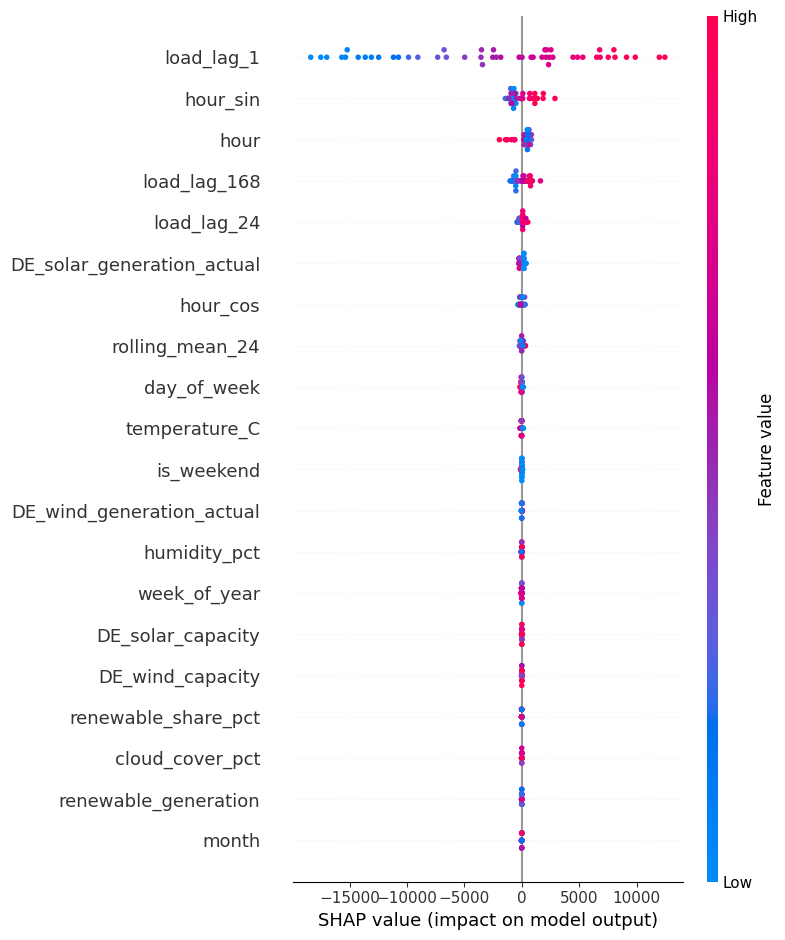

In [54]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values,
    X_sample,
    show=False
)

plt.tight_layout()
plt.show()

### SHAP Summary Analysis

The SHAP summary plot provides a global interpretation of the Random Forest model by quantifying both the importance and directional influence of each feature on electricity demand forecasts.

Consistent with the Random Forest feature importance analysis, **load_lag_1** emerged as the dominant predictor. High values of **load_lag_1** were associated with positive SHAP values, indicating that elevated demand during the previous hour tends to increase forecasted demand in the current hour. Conversely, low values of **load_lag_1** contributed negatively to demand forecasts.

Temporal variables such as **hour_sin**, **hour**, **load_lag_168**, and **load_lag_24** also exhibited meaningful influence, highlighting the importance of daily and weekly consumption cycles. The SHAP analysis confirms that historical demand patterns are the primary drivers of forecasting performance.

Weather-related variables, renewable generation metrics, and installed generation capacities showed comparatively small SHAP magnitudes, suggesting a limited contribution to short-term demand forecasting relative to autoregressive demand signals.

Overall, the SHAP results validate previous feature importance findings and demonstrate that the Random Forest model primarily relies on historical demand behavior and temporal consumption patterns to generate accurate forecasts.

## Mean Absolute SHAP Feature Importance

To quantify the average contribution of each feature to model predictions, mean absolute SHAP values were computed and visualized. This provides a global ranking of feature influence while accounting for both positive and negative effects.

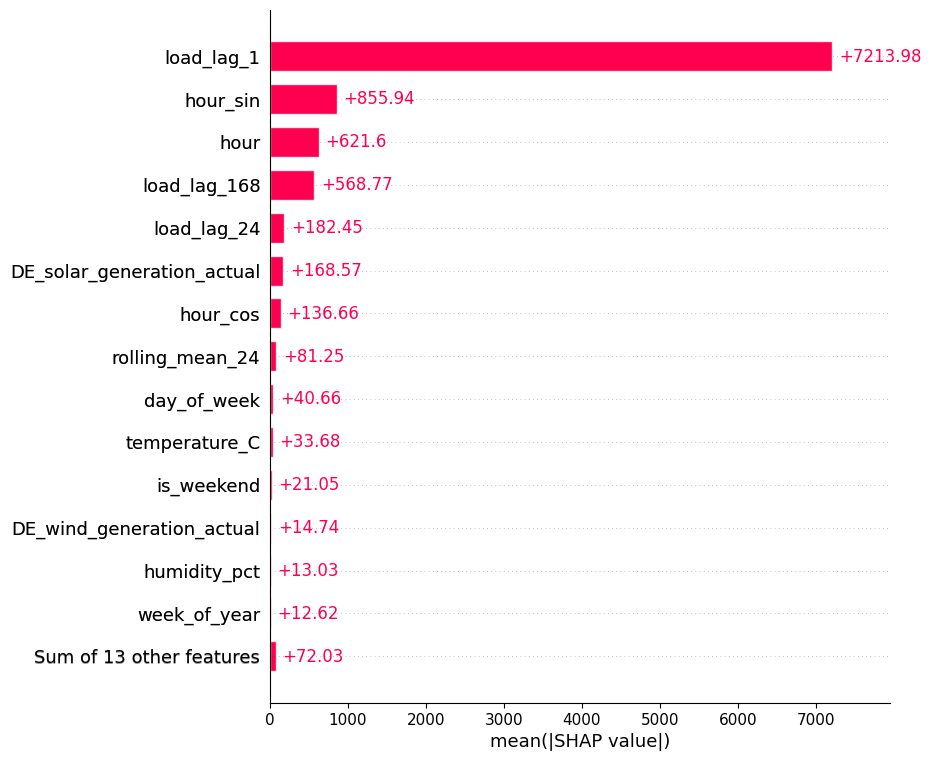

In [55]:
shap.plots.bar(
    shap.Explanation(
        values=shap_values,
        data=X_sample.values,
        feature_names=X_sample.columns
    ),
    max_display=15
)

### Mean Absolute SHAP Feature Importance

The mean absolute SHAP values provide a global ranking of feature influence across all analyzed forecasts. Consistent with previous Random Forest feature importance and SHAP summary analyses, **load_lag_1** emerged as the dominant predictor by a substantial margin.

The average contribution of **load_lag_1** (7,213.98) was more than eight times greater than the next most influential feature (**hour_sin**, 855.94). Additional important predictors included **hour**, **load_lag_168**, and **load_lag_24**, further highlighting the importance of temporal and historical demand information.

Renewable generation variables, weather conditions, and calendar-based features exhibited comparatively small SHAP magnitudes, indicating a secondary role in short-term demand forecasting. The results confirm that the forecasting model derives most of its predictive power from autoregressive demand signals and recurring consumption patterns.

The consistency between Random Forest feature importance, SHAP summary analysis, and SHAP mean absolute values provides strong evidence regarding the primary drivers of electricity demand within the dataset.

## Extreme Gradient Boosting (XGBoost)

XGBoost was evaluated as an advanced ensemble learning algorithm for electricity demand forecasting. Unlike Random Forest, which averages predictions from many independent trees, XGBoost builds trees sequentially, allowing each new tree to correct errors made by previous trees.

In [56]:
import xgboost

print(xgboost.__version__)

3.2.0


## Training the XGBoost Forecasting Model

An XGBoost Regressor was trained using the engineered feature set and the same chronological train-test split employed for previous forecasting models. This ensures a fair comparison of forecasting performance across machine learning algorithms.

### Gradient Boosting Approach

Unlike Random Forest, which constructs independent decision trees, XGBoost sequentially builds trees that focus on correcting residual errors from previous trees. This boosting strategy often achieves superior predictive accuracy for structured tabular datasets by capturing complex nonlinear interactions among features.

In [57]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

xgb_pred = xgb_model.predict(
    X_test
)

print("XGBoost trained successfully.")

XGBoost trained successfully.


### XGBoost Model Training

The XGBoost model was successfully trained using the engineered feature set and chronological train-test split. By sequentially correcting prediction errors from previous trees, XGBoost aims to improve forecasting accuracy beyond that achieved by Random Forest and Linear Regression models.

In [58]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

xgb_mae = mean_absolute_error(
    y_test,
    xgb_pred
)

xgb_rmse = root_mean_squared_error(
    y_test,
    xgb_pred
)

xgb_r2 = r2_score(
    y_test,
    xgb_pred
)

print("XGBoost MAE :", round(xgb_mae, 2))
print("XGBoost RMSE:", round(xgb_rmse, 2))
print("XGBoost R²  :", round(xgb_r2, 4))

XGBoost MAE : 534.47
XGBoost RMSE: 709.96
XGBoost R²  : 0.9948


### XGBoost Performance Evaluation

The XGBoost model achieved the best forecasting performance among all evaluated models, with an MAE of 534.47 MW, an RMSE of 709.96 MW, and an R² score of 0.9948.

Compared with Random Forest, XGBoost delivered modest but consistent improvements across all evaluation metrics. The RMSE decreased from 734.49 MW to 709.96 MW, while the R² score increased from 0.9944 to 0.9948. These results indicate that the boosting framework was able to capture additional nonlinear relationships and residual patterns present in the electricity demand data.

The findings demonstrate the effectiveness of ensemble tree-based methods for short-term electricity demand forecasting and establish XGBoost as the best-performing model within this study.

## Comparative Evaluation of Forecasting Models

The forecasting performance of all evaluated models was compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²). This comparison provides a comprehensive assessment of predictive accuracy and model effectiveness.

In [59]:
comparison_df = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost'
    ],
    'MAE': [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae
    ],
    'RMSE': [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],
    'R2': [
        baseline_r2,
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

comparison_df.sort_values(
    by='R2',
    ascending=False
)

,Model,MAE,RMSE,R2
3,XGBoost,534.467287,709.957481,0.994797
2,Random Forest,536.228592,734.493811,0.994431
1,Linear Regression,1168.197378,1490.436887,0.977070
0,Baseline,1877.816064,2461.993466,0.937431


## Feature Selection and Model Simplification

To evaluate whether all engineered features are necessary for accurate forecasting, a feature selection experiment was conducted. Features exhibiting consistently low importance across Random Forest and SHAP analyses were removed, and the XGBoost model was retrained using the reduced feature set.

This experiment assesses whether model complexity can be reduced without sacrificing predictive performance.

In [60]:
features_to_remove = [
    'cloud_cover_pct',
    'precipitation_mm',
    'humidity_pct',
    'DE_wind_capacity',
    'DE_solar_capacity',
    'renewable_generation'
]

X_train_reduced = X_train.drop(
    columns=features_to_remove
)

X_test_reduced = X_test.drop(
    columns=features_to_remove
)

print("Original features:", X_train.shape[1])
print("Reduced features :", X_train_reduced.shape[1])

Original features: 27
Reduced features : 21


### Reduced Feature Set

Six features with consistently low predictive importance were removed from the dataset. The resulting reduced feature set was used to evaluate whether comparable forecasting performance could be achieved with a simpler and more interpretable model.

In [61]:
from xgboost import XGBRegressor

xgb_reduced = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb_reduced.fit(
    X_train_reduced,
    y_train
)

xgb_reduced_pred = xgb_reduced.predict(
    X_test_reduced
)

print("Reduced XGBoost trained successfully.")

Reduced XGBoost trained successfully.


In [62]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score
)

xgb_reduced_mae = mean_absolute_error(
    y_test,
    xgb_reduced_pred
)

xgb_reduced_rmse = root_mean_squared_error(
    y_test,
    xgb_reduced_pred
)

xgb_reduced_r2 = r2_score(
    y_test,
    xgb_reduced_pred
)

print("Reduced XGBoost MAE :", round(xgb_reduced_mae, 2))
print("Reduced XGBoost RMSE:", round(xgb_reduced_rmse, 2))
print("Reduced XGBoost R²  :", round(xgb_reduced_r2, 4))

Reduced XGBoost MAE : 503.91
Reduced XGBoost RMSE: 673.69
Reduced XGBoost R²  : 0.9953


### Impact of Feature Selection on Forecasting Performance

The removal of six low-importance features resulted in an improvement in forecasting performance across all evaluation metrics. The reduced XGBoost model achieved an MAE of 503.91 MW, an RMSE of 673.69 MW, and an R² score of 0.9953, outperforming both the original XGBoost and Random Forest models.

These findings indicate that several weather-related and capacity-related variables contributed limited predictive value and may have introduced noise into the learning process. By eliminating weak predictors, the model was able to focus more effectively on the most informative demand, temporal, and renewable energy features.

The results demonstrate that feature selection not only simplifies the model but can also improve generalization performance by reducing unnecessary complexity.

In [68]:
final_comparison_df = pd.DataFrame({
    'Model': [
        'Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Reduced XGBoost'
    ],
    'MAE': [
        baseline_mae,
        lr_mae,
        rf_mae,
        xgb_mae,
        xgb_reduced_mae
    ],
    'RMSE': [
        baseline_rmse,
        lr_rmse,
        rf_rmse,
        xgb_rmse,
        xgb_reduced_rmse
    ],
    'R2': [
        baseline_r2,
        lr_r2,
        rf_r2,
        xgb_r2,
        xgb_reduced_r2
    ]
})

# Sort so the best model appears first
final_comparison_df = final_comparison_df.sort_values(
    by='R2',
    ascending=False
).reset_index(drop=True)

# Display styled table
final_comparison_df.style.highlight_max(
    subset=['R2'],
    color='#006400'
).highlight_min(
    subset=['MAE', 'RMSE'],
    color='#006400'
).set_properties(
    subset=['MAE', 'RMSE', 'R2'],
    **{'color': 'white'}
)

,Model,MAE,RMSE,R2
0,Reduced XGBoost,503.910974,673.691646,0.995315
1,XGBoost,534.467287,709.957481,0.994797
2,Random Forest,536.228592,734.493811,0.994431
3,Linear Regression,1168.197378,1490.436887,0.977070
4,Baseline,1877.816064,2461.993466,0.937431


### Final Model Ranking

The models were ranked according to forecasting performance, with the Reduced XGBoost model achieving the highest predictive accuracy. The combination of feature engineering, feature selection, and gradient boosting produced the lowest forecasting errors and highest explanatory power among all evaluated approaches.

The results demonstrate that removing low-importance features not only simplified the model but also improved predictive performance, highlighting the importance of feature selection in machine learning workflows.

Consequently, the Reduced XGBoost model was selected as the final forecasting model for subsequent analysis and potential deployment.

## Saving the Final Forecasting Model

The best-performing model identified during the evaluation process was the Reduced XGBoost model. The trained model was exported for future forecasting, deployment, and reproducibility purposes.

In [69]:
import joblib

joblib.dump(
    xgb_reduced,
    "../models/reduced_xgboost_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [70]:
loaded_model = joblib.load(
    "../models/reduced_xgboost_model.pkl"
)

print(type(loaded_model))

<class 'xgboost.sklearn.XGBRegressor'>


# Key Findings and Conclusions

This project developed and evaluated machine learning models for short-term electricity demand forecasting using German electricity system, weather, and renewable energy data. The workflow encompassed data collection, preprocessing, exploratory data analysis, feature engineering, model development, explainability analysis, and feature selection.

## Key Findings

### 1. Historical Demand is the Strongest Predictor

Correlation analysis, Random Forest feature importance, and SHAP explainability consistently identified historical demand variables as the most influential predictors of future electricity demand. In particular, **load_lag_1** emerged as the dominant feature across all analyses, demonstrating the strong persistence and temporal dependence of electricity consumption patterns.

### 2. Temporal Features Significantly Improve Forecast Accuracy

Engineered temporal features such as **hour_sin**, **hour_cos**, **load_lag_24**, **load_lag_168**, and **rolling_mean_24** captured daily and weekly consumption cycles effectively. These features contributed substantially to forecasting performance and enabled the models to learn recurring demand patterns.

### 3. Weather and Renewable Features Play a Secondary Role

Although weather variables and renewable energy indicators exhibited some predictive value, their influence was considerably smaller than that of historical demand and temporal features. SHAP analysis revealed that most weather-related variables contributed only marginally to model predictions compared with autoregressive demand signals.

### 4. Ensemble Learning Outperformed Traditional Statistical Methods

Machine learning models significantly outperformed the baseline and Linear Regression models. The progression from simple forecasting approaches to advanced ensemble methods resulted in substantial reductions in forecasting error and improvements in explanatory power.

### 5. Feature Selection Improved Model Performance

The removal of six low-importance features led to improved forecasting performance. This finding demonstrates that increasing the number of input variables does not necessarily improve predictive accuracy and that careful feature selection can reduce noise while enhancing model generalization.

## Model Performance Summary

The final comparison of forecasting models is summarized below:

| Model             |     MAE |    RMSE |     R² |
| ----------------- | ------: | ------: | -----: |
| Baseline          | 1877.82 | 2461.99 | 0.9374 |
| Linear Regression | 1168.20 | 1490.44 | 0.9771 |
| Random Forest     |  536.23 |  734.49 | 0.9944 |
| XGBoost           |  534.47 |  709.96 | 0.9948 |
| Reduced XGBoost   |  503.91 |  673.69 | 0.9953 |

The Reduced XGBoost model achieved the best overall performance, producing the lowest forecasting errors and highest coefficient of determination among all evaluated models.

## Explainability and Model Transparency

To improve interpretability, SHAP (SHapley Additive exPlanations) analysis was applied to the Random Forest model. The SHAP results confirmed the dominance of historical demand features and provided both global and local explanations of model behavior. The consistency between SHAP analysis, feature importance rankings, and feature ablation studies strengthens confidence in the reliability of the findings.

## Conclusions

This study demonstrates that short-term electricity demand forecasting can be performed with high accuracy using machine learning techniques combined with carefully engineered temporal and demand-related features. Historical electricity demand remains the primary driver of forecasting performance, while weather and renewable energy variables contribute supplementary predictive information.

Among all evaluated approaches, the Reduced XGBoost model emerged as the optimal forecasting solution, achieving an R² score of 0.9953 and outperforming both Random Forest and standard XGBoost models. The results highlight the importance of feature engineering, model explainability, and feature selection in developing robust forecasting systems.

Future work will focus on walk-forward validation to evaluate model robustness across multiple forecasting horizons and better assess real-world deployment performance on unseen future data.
